In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [17]:
# Importing Datasets
Flight_Level_Data = pd.read_csv('/content/Flight Level Data.csv')
Airports_Data = pd.read_csv('/content/Airports Data.csv')
Bag_Level_Data = pd.read_csv('/content/Bag+Level+Data.csv')
PNR_Flight_Level_Data = pd.read_csv('/content/PNR+Flight+Level+Data.csv')
PNR_Remark_Level_Data = pd.read_csv('/content/PNR Remark Level Data.csv')

In [18]:
Flight_Level_Data.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,fleet_type,carrier,scheduled_ground_time_minutes,actual_ground_time_minutes,minimum_turn_minutes
0,OO,4792,2025-08-04,ORD,ROA,2025-08-04T17:57:00Z,2025-08-04T21:04:00Z,2025-08-04T18:04:00Z,2025-08-04T20:52:00Z,76,ERJ-175,Express,42,34,34
1,UA,920,2025-08-03,ORD,LHR,2025-08-03T18:05:00Z,2025-08-04T08:20:00Z,2025-08-03T18:27:00Z,2025-08-04T08:06:00Z,167,B767-300,Mainline,235,229,145
2,UA,1776,2025-08-10,ORD,PHL,2025-08-10T18:20:00Z,2025-08-10T21:35:00Z,2025-08-10T20:11:00Z,2025-08-10T23:26:00Z,166,B737-800,Mainline,76,69,51
3,OO,5790,2025-08-06,ORD,CRW,2025-08-06T18:20:00Z,2025-08-06T21:04:00Z,2025-08-06T20:05:00Z,2025-08-06T22:42:00Z,50,CRJ-200,Express,223,38,29
4,UA,1398,2025-08-05,ORD,ATL,2025-08-05T18:20:00Z,2025-08-05T21:29:00Z,2025-08-05T18:16:00Z,2025-08-05T21:49:00Z,166,B737-800,Mainline,75,72,51


In [19]:
Airports_Data.head()

,airport_iata_code,iso_country_code
0,DAU,PG
1,MDU,PG
2,MXH,PG
3,MIS,PG
4,TIZ,PG


In [20]:

Bag_Level_Data.head()


,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,bag_tag_unique_number,bag_tag_issue_date,bag_type
0,UA,1068,2025-08-01,ORD,IAD,BAGTAG_418666,2025-07-27,Transfer
1,UA,622,2025-08-01,ORD,DEN,BAGTAG_418667,2025-07-28,Transfer
2,YX,3718,2025-08-01,ORD,MSN,BAGTAG_84760,2025-07-28,Transfer
3,BA,294,2025-08-01,ORD,LHR,BAGTAG_418669,2025-07-28,Transfer
4,UA,2627,2025-08-01,ORD,MSP,BAGTAG_335257,2025-07-28,Transfer


In [21]:
PNR_Flight_Level_Data.head()

,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,record_locator,pnr_creation_date,total_pax,is_child,basic_economy_ind,is_stroller_user,lap_child_count
0,UA,2494,2025-08-04,ORD,MCI,PNR_520583,2025-07-07,1,N,0,N,0
1,UA,2483,2025-08-06,ORD,IAH,PNR_296107,2025-03-28,1,N,0,N,0
2,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,Y,0,N,0
3,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,N,0,N,1
4,UA,1620,2025-08-01,ORD,SEA,PNR_296108,2025-06-30,4,Y,0,Y,0


In [22]:

PNR_Remark_Level_Data.head()

,record_locator,pnr_creation_date,flight_number,special_service_request
0,PNR_153489,2025-07-04,308,Airport Wheelchair
1,PNR_153489,2025-07-04,2182,Airport Wheelchair
2,PNR_153508,2025-07-10,2649,Airport Wheelchair
3,PNR_153508,2025-07-10,2100,Airport Wheelchair
4,PNR_153521,2025-03-01,970,Unaccompanied Minor


## Exploratory Data Analysis

Average delay & % late departures

In [23]:


Flight_Level_Data["scheduled_departure_datetime_local"] = pd.to_datetime(Flight_Level_Data["scheduled_departure_datetime_local"])
Flight_Level_Data["actual_departure_datetime_local"] = pd.to_datetime(Flight_Level_Data["actual_departure_datetime_local"])

# Calculate delay
Flight_Level_Data["departure_delay_min"] = ((Flight_Level_Data["actual_departure_datetime_local"] - Flight_Level_Data["scheduled_departure_datetime_local"]).dt.total_seconds() / 60)

avg_delay = Flight_Level_Data["departure_delay_min"].mean()
pct_late = (Flight_Level_Data["departure_delay_min"] > 0).mean() * 100

print(f"Average departure delay: {avg_delay:.2f} minutes")
print(f"Percentage of flights departing late: {pct_late:.2f}%")

Flight_Level_Data['departure_delay_min'].describe()


Average departure delay: 21.18 minutes
Percentage of flights departing late: 49.61%


,departure_delay_min
count,8099.000000
mean,21.184961
std,62.169868
min,-17.000000
25%,-4.000000
50%,0.000000
75%,18.000000
max,1017.000000


Flights with scheduled ground time <= minimum turn

In [50]:
Flight_Level_Data["scheduled_ground_time_minutes"] = pd.to_numeric(Flight_Level_Data["scheduled_ground_time_minutes"], errors="coerce")
Flight_Level_Data["minimum_turn_minutes"] = pd.to_numeric(Flight_Level_Data["minimum_turn_minutes"], errors="coerce")
Flight_Level_Data["ground_time_diff"] = (Flight_Level_Data["scheduled_ground_time_minutes"] - Flight_Level_Data["minimum_turn_minutes"])

CLOSE_THRESHOLD = 10

Flight_Level_Data["below_min_turn"] = Flight_Level_Data["ground_time_diff"] < 0
Flight_Level_Data["close_to_min_turn"] = (Flight_Level_Data["ground_time_diff"].between(0, CLOSE_THRESHOLD, inclusive="both"))
Flight_Level_Data["at_or_below_close"] = (Flight_Level_Data["below_min_turn"] | Flight_Level_Data["close_to_min_turn"])

total_flights = len(Flight_Level_Data)
below_count = Flight_Level_Data["below_min_turn"].sum()
close_count = Flight_Level_Data["close_to_min_turn"].sum()
combined_count = Flight_Level_Data["at_or_below_close"].sum()

print("Ground Time vs Minimum Turn Summary")
print(f"Total flights: {total_flights}")
print(f"Flights BELOW minimum turn: {below_count} ({below_count/total_flights*100:.2f}%)")
print(f"Flights WITHIN {CLOSE_THRESHOLD} mins of minimum: {close_count} ({close_count/total_flights*100:.2f}%)")
print(f"Total flights AT or BELOW (combined): {combined_count} ({combined_count/total_flights*100:.2f}%)")

station_summary = (Flight_Level_Data.groupby("scheduled_departure_station_code")["at_or_below_close"].mean().reset_index().rename
 (columns={"at_or_below_close": "Pct_At_or_Below_Close"}))

station_summary["Pct_At_or_Below_Close"] *= 100

print("\nTop 10 Stations with Highest % of Tight Ground Time Flights:")
print(station_summary.sort_values("Pct_At_or_Below_Close", ascending=False).head(10))


Ground Time vs Minimum Turn Summary
Total flights: 8099
Flights BELOW minimum turn: 630 (7.78%)
Flights WITHIN 10 mins of minimum: 553 (6.83%)
Total flights AT or BELOW (combined): 1183 (14.61%)

Top 10 Stations with Highest % of Tight Ground Time Flights:
  scheduled_departure_station_code  Pct_At_or_Below_Close
0                              ORD              14.606742


Avg. ratio of transfer vs. checked bags

In [25]:
# Group by flight and bag type to count number of bags
bag_counts = (Bag_Level_Data.groupby(["flight_number", "scheduled_departure_date_local", "bag_type"]).size().unstack(fill_value=0))

# Transfer + Hot Transfer as total transfer bags
bag_counts["total_transfer_bags"] = (bag_counts.get("Transfer", 0) + bag_counts.get("Hot Transfer", 0))

# 'Origin' represents checked bags
bag_counts["checked_bags"] = bag_counts.get("Origin", 0)

# avoid division by zero int the ratio calculation
bag_counts["transfer_to_checked_ratio"] = (bag_counts["total_transfer_bags"] / bag_counts["checked_bags"].replace(0, np.nan))

# average ratio across all flights
avg_bag_ratio = bag_counts["transfer_to_checked_ratio"].mean(skipna=True)

print(f"Average ratio of transfer bags to checked bags: {avg_bag_ratio:.2f}")

Average ratio of transfer bags to checked bags: 3.75


Passenger loads vs operational difficulty (delay)

In [26]:
PNR_Flight_Level_Data["scheduled_departure_date_local"] = pd.to_datetime(PNR_Flight_Level_Data["scheduled_departure_date_local"]).dt.date

Flight_Level_Data["scheduled_departure_date_local"] = pd.to_datetime(Flight_Level_Data["scheduled_departure_date_local"]).dt.date

# Aggregate load
load_vs_delay = PNR_Flight_Level_Data.groupby(["flight_number", "scheduled_departure_date_local"]).agg({"total_pax": "sum"}).reset_index()

# Merge with delays
load_vs_delay = load_vs_delay.merge(Flight_Level_Data[["flight_number", "scheduled_departure_date_local", "departure_delay_min"]],on=["flight_number", "scheduled_departure_date_local"],how="inner")

corr_load_delay = load_vs_delay["total_pax"].corr(load_vs_delay["departure_delay_min"])
print(f"Correlation between passenger load and delay: {corr_load_delay:.2f}")


Correlation between passenger load and delay: -0.02


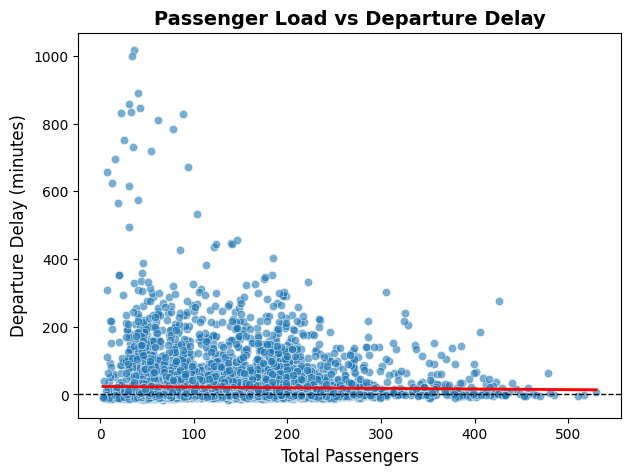

In [27]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=load_vs_delay,
    x="total_pax",
    y="departure_delay_min",
    alpha=0.6)

# regression trendline
sns.regplot(data=load_vs_delay,x="total_pax",y="departure_delay_min",scatter=False,color="red",line_kws={"lw":2})

plt.title("Passenger Load vs Departure Delay", fontsize=14, weight="bold")
plt.xlabel("Total Passengers", fontsize=12)
plt.ylabel("Departure Delay (minutes)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

High SSR vs delay (controlling for load)

/tmp/ipython-input-3523785372.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


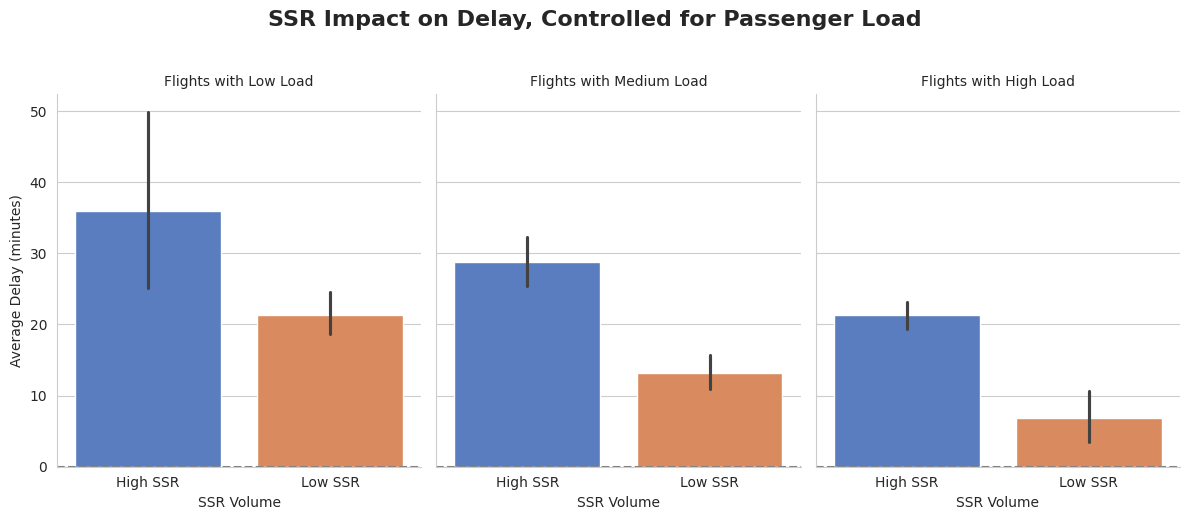

In [51]:
# Data Loading and Preparation
flight_df = pd.read_csv('Flight Level Data.csv')

pnr_flight_df = pd.read_csv('PNR+Flight+Level+Data.csv')
pnr_remark_df = pd.read_csv('PNR Remark Level Data.csv')

# Convert date/time columns and calculate delay
flight_df['scheduled_departure_datetime_local'] = pd.to_datetime(flight_df['scheduled_departure_datetime_local'])
flight_df['actual_departure_datetime_local'] = pd.to_datetime(flight_df['actual_departure_datetime_local'])
flight_df['departure_delay_min'] = (flight_df['actual_departure_datetime_local'] - flight_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60
# Create a consistent date column for merging
flight_df['scheduled_departure_date'] = flight_df['scheduled_departure_datetime_local'].dt.date
pnr_flight_df['scheduled_departure_date'] = pd.to_datetime(pnr_flight_df['scheduled_departure_date_local']).dt.date

# Merge remarks to get consistent dates
ssr_with_date = pnr_remark_df.merge(flight_df[['flight_number', 'scheduled_departure_date']], on='flight_number', how='left')
# Aggregate SSR counts
ssr_counts = ssr_with_date.groupby(['flight_number', 'scheduled_departure_date']).size().reset_index(name='ssr_count')
# Aggregate passenger counts
pax_counts = pnr_flight_df.groupby(['flight_number', 'scheduled_departure_date']).agg(total_pax=('total_pax', 'sum')).reset_index()
# Merge all data into a single DataFrame
analysis_df = flight_df.merge(pax_counts, on=['flight_number', 'scheduled_departure_date'], how='left')
analysis_df = analysis_df.merge(ssr_counts, on=['flight_number', 'scheduled_departure_date'], how='left')
analysis_df.fillna(0, inplace=True)

# Categories for Load and SSR
# three passenger load categories based on quantiles (tertiles)
analysis_df['load_category'] = pd.qcut(analysis_df['total_pax'],q=3,labels=['Low Load', 'Medium Load', 'High Load'])

# a binary flag for high vs. low SSR count based on the median
median_ssr = analysis_df['ssr_count'].median()
analysis_df['ssr_volume'] = np.where(analysis_df['ssr_count'] > median_ssr, 'High SSR', 'Low SSR')

# Visualization

# catplot to create a faceted bar plot
g = sns.catplot(data=analysis_df,x='ssr_volume',

                # Compare Low vs. High SSR

    y='departure_delay_min',
    col='load_category',   # Create a separate plot for each load category
    kind='bar',
    palette='muted',
    height=5,
    aspect=0.8,
    errorbar='ci')

# Refine plot aesthetics
g.fig.suptitle('SSR Impact on Delay, Controlled for Passenger Load', y=1.03, fontsize=16, weight='bold')
g.set_axis_labels("SSR Volume", "Average Delay (minutes)")
g.set_titles("Flights with {col_name}")
g.refline(y=0, linestyle='--', color='grey')
plt.tight_layout()
plt.show()


## Flight Difficulty Score Development

In [52]:
# Prepare aggregated data per flight per day
# Aggregate PNR Flight Level: passenger metrics
pax_agg = PNR_Flight_Level_Data.groupby(['flight_number', 'scheduled_departure_date_local']).agg({'total_pax': 'sum','lap_child_count': 'sum'}).reset_index()

# Aggregate child count (based on is_child)
child_count = PNR_Flight_Level_Data[PNR_Flight_Level_Data['is_child'] == 'Y'].groupby(['flight_number', 'scheduled_departure_date_local']).size().reset_index(name='child_count')
pax_agg = pax_agg.merge(child_count, on=['flight_number', 'scheduled_departure_date_local'], how='left')
pax_agg['child_count'] = pax_agg['child_count'].fillna(0)
pax_agg['total_children'] = pax_agg['lap_child_count'] + pax_agg['child_count']

# Aggregate basic_economy_ind count
basic_economy_count = PNR_Flight_Level_Data[PNR_Flight_Level_Data['basic_economy_ind'] == 'Y'].groupby(['flight_number', 'scheduled_departure_date_local']).size().reset_index(name='basic_economy_count')
pax_agg = pax_agg.merge(basic_economy_count, on=['flight_number', 'scheduled_departure_date_local'], how='left')
pax_agg['basic_economy_count'] = pax_agg['basic_economy_count'].fillna(0)

# Aggregate SSR counts
ssr_with_date = PNR_Remark_Level_Data.merge(Flight_Level_Data[['flight_number', 'scheduled_departure_date_local']],
on='flight_number',how='left')

ssr_counts = ssr_with_date.groupby(['flight_number', 'scheduled_departure_date_local']).size().reset_index(name='ssr_count')

# Aggregate Bag data
bag_agg = Bag_Level_Data.groupby(['flight_number', 'scheduled_departure_date_local']).agg({'bag_tag_unique_number': 'count'}).reset_index()
bag_agg.rename(columns={'bag_tag_unique_number': 'total_bags'}, inplace=True)

transfer_count = Bag_Level_Data[Bag_Level_Data['bag_type'] == 'Transfer'].groupby(['flight_number', 'scheduled_departure_date_local']).size().reset_index(name='transfer_bags')
checked_count = Bag_Level_Data[Bag_Level_Data['bag_type'] == 'Checked'].groupby(['flight_number', 'scheduled_departure_date_local']).size().reset_index(name='checked_bags')

bag_agg = bag_agg.merge(transfer_count, on=['flight_number', 'scheduled_departure_date_local'], how='left').merge(checked_count, on=['flight_number', 'scheduled_departure_date_local'], how='left')
bag_agg[['transfer_bags', 'checked_bags']] = bag_agg[['transfer_bags', 'checked_bags']].fillna(0)
bag_agg['transfer_ratio'] = bag_agg['transfer_bags'] / (bag_agg['checked_bags'] + 1)  # Avoid division by zero

# Merge all into Flight_Level_Data
flight_df = Flight_Level_Data.merge(pax_agg, on=['flight_number', 'scheduled_departure_date_local'], how='left')
flight_df = flight_df.merge(ssr_counts, on=['flight_number', 'scheduled_departure_date_local'], how='left')
flight_df = flight_df.merge(bag_agg, on=['flight_number', 'scheduled_departure_date_local'], how='left')


# Fill NaNs
flight_df[['total_pax', 'total_children', 'basic_economy_count', 'ssr_count', 'total_bags', 'transfer_ratio']] = flight_df[['total_pax', 'total_children', 'basic_economy_count', 'ssr_count', 'total_bags', 'transfer_ratio']].fillna(0)

# Feature Engineering
flight_df['pax_load_ratio'] = flight_df['total_pax'] / flight_df['total_seats']
flight_df['ground_constraint'] = np.where(flight_df['scheduled_ground_time_minutes'] <= flight_df['minimum_turn_minutes'], 1, 0)
flight_df['bag_load'] = flight_df['total_bags'] / flight_df['total_seats']  # Bags per seat

#Select features for scoring
features = ['ground_constraint', 'pax_load_ratio', 'ssr_count', 'total_children', 'bag_load', 'transfer_ratio', 'basic_economy_count']

# Normalize features per day
def normalize_daily(group):
    scaler = MinMaxScaler()
    #Explicitly select only the feature columns, excluding scheduled_departure_date_local
    feature_cols = group[features]
    group[features] = scaler.fit_transform(feature_cols)
    return group

flight_df = flight_df.groupby('scheduled_departure_date_local', group_keys=False).apply(normalize_daily).reset_index(drop=True)

# Compute Difficulty Score (equal weights for simplicity; can adjust based on EDA correlations)
flight_df['difficulty_score'] = flight_df[features].sum(axis=1) / len(features)

#Daily Ranking:
#Higher score = higher difficulty (rank 1 = most difficult)
flight_df['daily_rank'] = flight_df.groupby('scheduled_departure_date_local')['difficulty_score'].rank(ascending=False, method='dense')

# Classification: Based on rank distribution
def classify(row, group):

    ranks = group['daily_rank']
    tertiles = np.percentile(ranks, [33.33, 66.67])
    if row['daily_rank'] <= tertiles[0]:
      return 'Difficult'
    elif row['daily_rank'] <= tertiles[1]:
      return 'Medium'
    else:
      return 'Easy'

flight_df['difficulty_class'] = flight_df.groupby('scheduled_departure_date_local', group_keys=False).apply(lambda g: g.apply(lambda row: classify(row, g.drop(columns=['scheduled_departure_date_local'])), axis=1)
).reset_index(level=0, drop=True)

# Output to CSV
output_cols = ['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code',
'scheduled_arrival_station_code', 'difficulty_score', 'daily_rank', 'difficulty_class'] + features

flight_df[output_cols].to_csv('difficulty score.csv', index=False)

print("Flight Difficulty Score computed and saved to test_your_name.csv")


/tmp/ipython-input-629617199.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flight_df = flight_df.groupby('scheduled_departure_date_local', group_keys=False).apply(normalize_daily).reset_index(drop=True)


Flight Difficulty Score computed and saved to test_your_name.csv


/tmp/ipython-input-629617199.py:79: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  flight_df['difficulty_class'] = flight_df.groupby('scheduled_departure_date_local', group_keys=False).apply(lambda g: g.apply(lambda row: classify(row, g.drop(columns=['scheduled_departure_date_local'])), axis=1)


# Alternative Flight Difficulty Score

In [30]:
# Aggregate bag counts per flight
bag_counts = (Bag_Level_Data.groupby(["flight_number", "scheduled_departure_date_local", "bag_type"]).size().unstack(fill_value=0))

# Normalize bag type labels if needed
bag_counts.columns = bag_counts.columns.str.lower().str.strip()
# Compute total transfer bags and checked bags
bag_counts['total_transfer_bags'] = bag_counts.get('transfer', 0) + bag_counts.get('hot transfer', 0)
bag_counts['checked_bags'] = bag_counts.get('origin', 0)

# Compute transfer-to-checked ratio (handle zero checked bags)
bag_counts['transfer_to_checked_ratio'] = bag_counts['total_transfer_bags'] / bag_counts['checked_bags'].replace(0, np.nan)
bag_counts['transfer_to_checked_ratio'] = bag_counts['transfer_to_checked_ratio'].fillna(0)  # assume 0 if no checked bags
# Reset index for merging
bag_counts = bag_counts.reset_index()[['flight_number', 'scheduled_departure_date_local', 'transfer_to_checked_ratio']]
# Merge Features into Flight_Level_Data

flights = Flight_Level_Data.copy()
# Merge passenger counts
flights = flights.merge(pax_agg[['flight_number', 'scheduled_departure_date_local', 'total_pax']], on=['flight_number', 'scheduled_departure_date_local'], how='left')
flights['total_pax'] = flights['total_pax'].fillna(0)

# Merge SSR counts
flights = flights.merge(ssr_counts, on=['flight_number', 'scheduled_departure_date_local'], how='left')
flights['ssr_count'] = flights['ssr_count'].fillna(0)
# Merge bag ratio
flights = flights.merge(bag_counts, on=['flight_number', 'scheduled_departure_date_local'], how='left')
flights['transfer_to_checked_ratio'] = flights['transfer_to_checked_ratio'].fillna(0)  # fill missing
# Compute SSR per passenger
flights['SSR_per_passenger'] = flights['ssr_count'] / flights['total_pax'].replace(0, np.nan)
flights['SSR_per_passenger'] = flights['SSR_per_passenger'].fillna(0)

# Compute tight ground time factor
flights['ground_time_risk'] = ((flights['scheduled_ground_time_minutes'] - flights['minimum_turn_minutes']) <= 0).astype(int)

# Use existing total_seats from Flight_Level_Data
flights['load_ratio'] = flights['total_pax'] / flights['total_seats'].replace(0, np.nan)
flights['load_ratio'] = flights['load_ratio'].fillna(0)

# Normalize Features

scaler = MinMaxScaler()
features_to_scale = ['transfer_to_checked_ratio', 'SSR_per_passenger', 'load_ratio']
flights[features_to_scale] = scaler.fit_transform(flights[features_to_scale])

#TODO: ground_time_risk is binary, no scaling
# Assign weights to each factor (customizable)
weights = {'transfer_to_checked_ratio': 0.25,'SSR_per_passenger': 0.25,'load_ratio': 0.25,'ground_time_risk': 0.25}

flights['difficulty_score'] = (flights['transfer_to_checked_ratio'] * weights['transfer_to_checked_ratio'] +
flights['SSR_per_passenger'] * weights['SSR_per_passenger'] +
flights['load_ratio'] * weights['load_ratio'] +
flights['ground_time_risk'] * weights['ground_time_risk'])

# Rank and classify flights per day
flights['daily_rank'] = flights.groupby('scheduled_departure_date_local')['difficulty_score'] \.rank(method='first', ascending=False)

# Classify top 33% as Difficult, middle 34% as Medium, bottom 33% as Easy
def classify_group(group):
    n = len(group)
    bins = [0, n/3, 2*n/3, n]
    labels = ['Easy', 'Medium', 'Difficult']
    return pd.cut(group['daily_rank'], bins=bins, labels=labels, include_lowest=True)

flights['difficulty_category'] = flights.groupby('scheduled_departure_date_local', group_keys=False).apply(classify_group, include_groups=False)

# Optional: Inspect results
print(flights[['flight_number', 'scheduled_departure_date_local', 'difficulty_score', 'daily_rank', 'difficulty_category']].head())

   flight_number scheduled_departure_date_local  difficulty_score  daily_rank  \
0           4792                     2025-08-04          0.135676       479.0   
1            920                     2025-08-03          0.146282       407.0   
2           1776                     2025-08-10          0.149066       336.0   
3           5790                     2025-08-06          0.165246       125.0   
4           1398                     2025-08-05          0.134094       411.0   

  difficulty_category  
0           Difficult  
1           Difficult  
2              Medium  
3                Easy  
4           Difficult  


## Post-Analysis & Operational Insights

In [31]:
# Load
difficulty_df = pd.read_csv('difficulty score.csv')

# Load Airports Data for destination names
airports_data = pd.read_csv('/content/Airports Data.csv')

# Merge to get destination names
difficulty_df = difficulty_df.merge(airports_data, left_on='scheduled_arrival_station_code', right_on='airport_iata_code', how='left')

# destinations with consistently high difficulty


# average difficulty score and % Difficult flights per destination
dest_analysis = difficulty_df.groupby('scheduled_arrival_station_code').agg({
    'difficulty_score': 'mean',
    'difficulty_class': lambda x: (x == 'Difficult').mean() * 100  # % Difficult
}).reset_index()
dest_analysis.columns = ['Destination_Code', 'Avg_Difficulty_Score', 'Pct_Difficult_Flights']

# top 5 most difficult destinations (by avg score)
top_difficult_dests = dest_analysis.nlargest(5, 'Avg_Difficulty_Score')
print("Top 5 Destinations with Highest Average Difficulty:")
print(top_difficult_dests)

# Common drivers for those flights


# For top difficult destinations, average feature values are:
features = ['ground_constraint', 'pax_load_ratio', 'ssr_count', 'total_children', 'bag_load', 'transfer_ratio', 'basic_economy_count']
top_dests_codes = top_difficult_dests['Destination_Code'].tolist()
drivers_analysis = difficulty_df[difficulty_df['scheduled_arrival_station_code'].isin(top_dests_codes)].groupby('scheduled_arrival_station_code')[features].mean().reset_index()

print("\nCommon Drivers for Top Difficult Destinations (Average Feature Values):")
print(drivers_analysis.round(3))

# overall common drivers (features with highest average across top dests)
overall_drivers = drivers_analysis[features].mean().sort_values(ascending=False)
print("\nOverall Highest Drivers Across Top Destinations:")
for feature, value in overall_drivers.items():
    print(f"{feature}: {value:.3f}")

# Specific actions based on findings


# Simple rule-based recommendations
recommendations = []
if overall_drivers.get('ssr_count', 0) > 0.5:recommendations.append("Increase special service staff allocation for high-SSR destinations.")
if overall_drivers.get('ground_constraint', 0) > 0.5:recommendations.append("Prioritize ground crew for flights with tight turnaround times.")
if overall_drivers.get('pax_load_ratio', 0) > 0.7:recommendations.append("Scale boarding assistance based on high passenger loads.")
if overall_drivers.get('transfer_ratio', 0) > 0.5:recommendations.append("Enhance bag transfer coordination for high-transfer routes.")
if overall_drivers.get('bag_load', 0) > 0.5:recommendations.append("Boost baggage handling resources for high bag volume flights.")

print("\nRecommended Actions for Operational Efficiency:")
for rec in recommendations:
    print(f"- {rec}")

# Save
dest_analysis.to_csv('destination_difficulty_summary.csv', index=False)
drivers_analysis.to_csv('drivers_analysis.csv', index=False)
print("\nAnalysis saved to 'destination_difficulty_summary.csv' and 'drivers_analysis.csv'.")


Top 5 Destinations with Highest Average Difficulty:
    Destination_Code  Avg_Difficulty_Score  Pct_Difficult_Flights
122              NAS              0.370651              50.000000
22               BRU              0.353158              46.666667
10               AUA              0.302632              75.000000
73               GRU              0.295796              46.666667
41               CUN              0.283391              23.333333

Common Drivers for Top Difficult Destinations (Average Feature Values):
  scheduled_arrival_station_code  ground_constraint  pax_load_ratio  \
0                            AUA              1.000           0.691   
1                            BRU              0.333           0.704   
2                            CUN              0.367           0.856   
3                            GRU              0.000           0.633   
4                            NAS              1.000           0.850   

   ssr_count  total_children  bag_load  transfer_rat

Most Difficult Destinations

In [32]:
# Most Difficult Destinations

destination_difficulty = flights.groupby('scheduled_arrival_station_code')['difficulty_score'].mean().sort_values(ascending=False)
print("Top 10 most difficult destinations:\n", destination_difficulty.head(10))

Top 10 most difficult destinations:
 scheduled_arrival_station_code
NAS    0.455568
AUA    0.418093
YHZ    0.401719
CUN    0.278663
MBJ    0.259750
BRU    0.253044
ONT    0.242443
MTY    0.231909
YVR    0.228342
PUJ    0.226299
Name: difficulty_score, dtype: float64


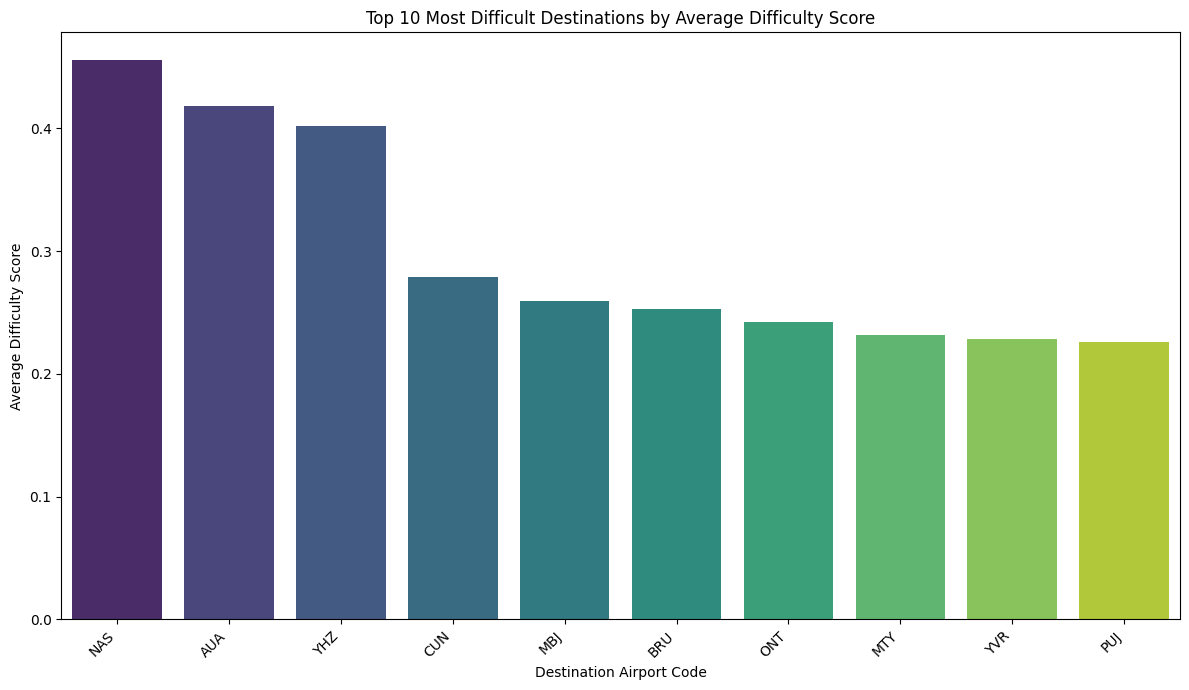

In [33]:
plt.figure(figsize=(12, 7))
sns.barplot(x=destination_difficulty.head(10).index, y=destination_difficulty.head(10).values, palette='viridis', hue=destination_difficulty.head(10).index, legend=False)
plt.title('Top 10 Most Difficult Destinations by Average Difficulty Score')
plt.xlabel('Destination Airport Code')
plt.ylabel('Average Difficulty Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Pax vs Delay Data

In [34]:
def export_pax_vs_delay_data():
  #Extracts and combines passenger load and departure delay data, then exports it to a CSV file.

    try:
        # Load the required datasets
        print("Loading Flight Level and PNR Flight Level data...")
        flight_df = pd.read_csv('Flight Level Data.csv')
        pnr_flight_df = pd.read_csv('PNR+Flight+Level+Data.csv')
        print("Data loaded successfully.")

        # Departure Delay
        print("Calculating departure delays...")
        # Convert date/time columns to datetime objects
        flight_df['scheduled_departure_datetime_local'] = pd.to_datetime(flight_df['scheduled_departure_datetime_local'])
        flight_df['actual_departure_datetime_local'] = pd.to_datetime(flight_df['actual_departure_datetime_local'])
    # delay in minutes
        flight_df['departure_delay_min'] = (flight_df['actual_departure_datetime_local'] - flight_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60

      # a simple date column for merging
        flight_df['scheduled_departure_date'] = flight_df['scheduled_departure_datetime_local'].dt.date
        pnr_flight_df['scheduled_departure_date'] = pd.to_datetime(pnr_flight_df['scheduled_departure_date_local']).dt.date
    # Aggregate Passenger Load
        print("Aggregating total passenger counts per flight...")
        pax_agg = pnr_flight_df.groupby(['flight_number', 'scheduled_departure_date']).agg(total_pax=('total_pax', 'sum')).reset_index()

        # Merge DataFrames
        print("Merging delay data with passenger data...")
        # Combine the delay information with the aggregated passenger counts
        pax_vs_delay_df = flight_df.merge(pax_agg,on=['flight_number', 'scheduled_departure_date'],how='inner'  )

        # Export
        # Select and rename columns for a clean output file
        output_df = pax_vs_delay_df[['flight_number','scheduled_departure_date','total_pax','departure_delay_min']]

        csv_filename = 'pax_vs_delay_data.csv'
        output_df.to_csv(csv_filename, index=False, float_format='%.2f')

        print(f"\nSuccessfully exported the analysis data to '{csv_filename}'")
        print("\nFirst 5 rows of the new data:")
        print(output_df.head())

    except FileNotFoundError:
        print("\nERROR: Could not find 'Flight Level Data.csv' or 'PNR+Flight+Level+Data.csv'. Please ensure both files are uploaded.")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

# Run the main function
if __name__ == '__main__':
    export_pax_vs_delay_data()


Loading Flight Level and PNR Flight Level data...
Data loaded successfully.
Calculating departure delays...
Aggregating total passenger counts per flight...
Merging delay data with passenger data...

Successfully exported the analysis data to 'pax_vs_delay_data.csv'

First 5 rows of the new data:
   flight_number scheduled_departure_date  total_pax  departure_delay_min
0           4792               2025-08-04         65                  7.0
1            920               2025-08-03        171                 22.0
2           1776               2025-08-10        180                111.0
3           5790               2025-08-06         55                105.0
4           1398               2025-08-05        136                 -4.0


Feature Contribtion using Gini Improtance

Loading 'difficulty score.csv'...
Dataset loaded successfully.
Training a Decision Tree model...
Model training complete.

Successfully exported feature contribution data to 'feature_contribution.csv'

--- Feature Contribution Ranking (based on Gini Importance) ---
               Feature  Gini_Importance_Contribution
1       pax_load_ratio                      0.372040
2            ssr_count                      0.336188
3       total_children                      0.270217
0    ground_constraint                      0.021555
4             bag_load                      0.000000
5       transfer_ratio                      0.000000
6  basic_economy_count                      0.000000


/tmp/ipython-input-2042477132.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


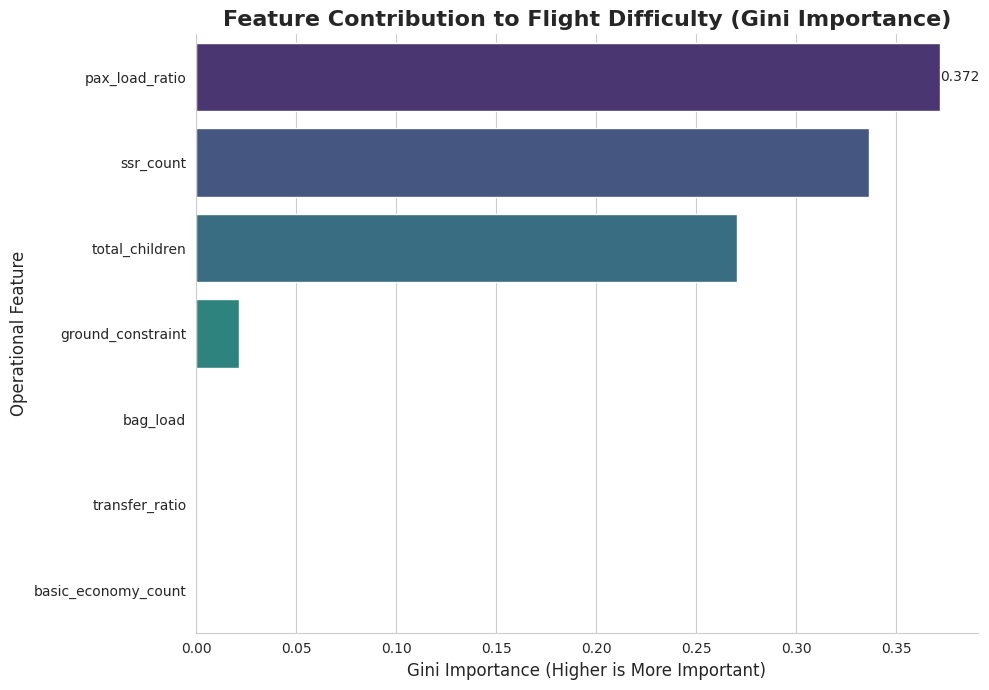

In [41]:
def calculate_feature_contribution():

    # Trains a Decision Tree model to predict flight difficulty and then calculates
    # the Gini Importance of each feature to determine its contribution.

    try:
        # Load Data
        print("Loading 'difficulty score.csv'...")
        data = pd.read_csv('difficulty score.csv')
        print("Dataset loaded successfully.")

        # Define Features (X) and Target (y)
        features = ['ground_constraint', 'pax_load_ratio', 'ssr_count','total_children', 'bag_load', 'transfer_ratio', 'basic_economy_count']

        target = 'difficulty_class'

        data.dropna(subset=features + [target], inplace=True)
        X = data[features]
        y = data[target]

        # Train a Decision Tree Model

        print("Training a Decision Tree model...")
        model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
        model.fit(X, y)
        print("Model training complete.")

        # Gini Importance
        importances = model.feature_importances_

        # a dataframe to display the results clearly.
        feature_contribution_df = pd.DataFrame({'Feature': features,'Gini_Importance_Contribution': importances}).sort_values(by='Gini_Importance_Contribution', ascending=False)

        # Export to CSV and Display
        csv_filename = 'feature_contribution.csv'
        feature_contribution_df.to_csv(csv_filename, index=False, float_format='%.4f')

        print(f"\nSuccessfully exported feature contribution data to '{csv_filename}'")
        print("\nFeature Contribution Ranking (based on Gini Importance)")
        print(feature_contribution_df)

        # Visualize
        plt.figure(figsize=(10, 7))
        sns.set_style("whitegrid")
        ax = sns.barplot(
            data=feature_contribution_df,
            x='Gini_Importance_Contribution',
            y='Feature',
            palette='viridis'
        )
        ax.bar_label(ax.containers[0], fmt='%.3f')
        sns.despine()
        plt.title('Feature Contribution to Flight Difficulty (Gini Importance)', fontsize=16, weight='bold')
        plt.xlabel('Gini Importance (Higher is More Important)', fontsize=12)
        plt.ylabel('Operational Feature', fontsize=12)
        plt.tight_layout()
        plt.savefig('feature_contribution_plot.png')
        plt.show()

    except FileNotFoundError:
        print("\nERROR: 'difficulty score.csv' not found. Please ensure this file is available.")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

# Run the main function
if __name__ == '__main__':
    calculate_feature_contribution()

A Correlation Matrix between features calculating Difficulty

Loading 'difficulty score.csv'...
Dataset loaded successfully.
Performing train-test split for sampling (80% train, 20% test)...
Sample size for correlation matrix: 6479 rows
Calculating the correlation matrix on the training data...
Generating heatmap visualization...

Successfully generated 'feature_correlation_heatmap.png'


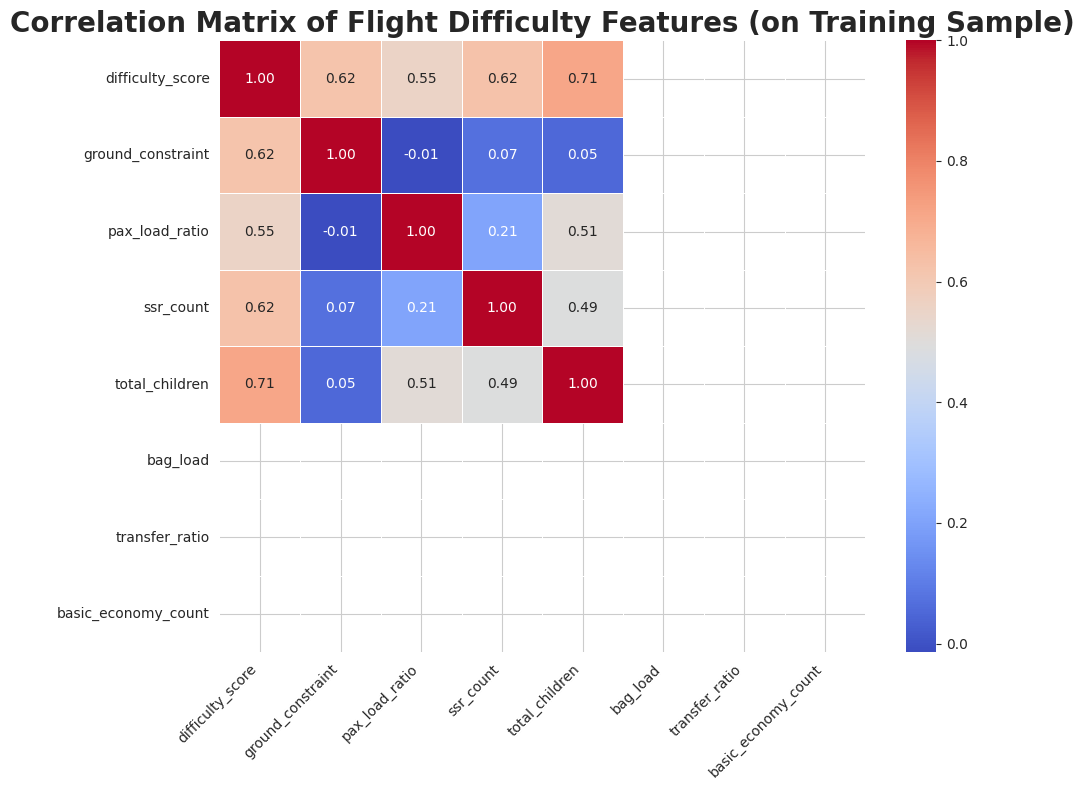

In [44]:
def create_correlation_heatmap():

    #Loads feature data, performs a train-test split for sampling, and
    #generates a heatmap of the correlation matrix for the training data.

    try:
        print("Loading 'difficulty score.csv'...")
        data = pd.read_csv('difficulty score.csv')
        print("Dataset loaded successfully.")

        features_for_corr = ['difficulty_score','ground_constraint',
            'pax_load_ratio','ssr_count','total_children','bag_load',
            'transfer_ratio','basic_economy_count']

        # a new DataFrame with just these columns, dropping any rows with nulls
        corr_df = data[features_for_corr].dropna()
        # Perform Sampling using Train-Test Split
        print("Performing train-test split for sampling (80% train, 20% test)...")
        train_df, test_df = train_test_split(corr_df, test_size=0.2, random_state=42)
        print(f"Sample size for correlation matrix: {len(train_df)} rows")
# Calculate the Correlation Matrix on the Training Sample
        print("Calculating the correlation matrix on the training data...")
        correlation_matrix = train_df.corr()



        # Generate the Heatmap
        print("Generating heatmap visualization...")
        plt.figure(figsize=(10, 8))

        sns.heatmap(
            correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5
        )

        # Style
        plt.title('Correlation Matrix of Flight Difficulty Features (on Training Sample)', fontsize=20, weight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()

        # Save
        plt.savefig('feature_correlation_heatmap.png')

        print("\nSuccessfully generated 'feature_correlation_heatmap.png'")
        plt.show()

    except FileNotFoundError:
        print("\nERROR: 'difficulty score.csv' not found. Please ensure this file is available.")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

# Run the function
if __name__ == '__main__':
    create_correlation_heatmap()




SSR vs Delay

Loading flight and SSR data...
Generating scatter plot...

Successfully generated 'destination_ssr_vs_delay_scatter.png'


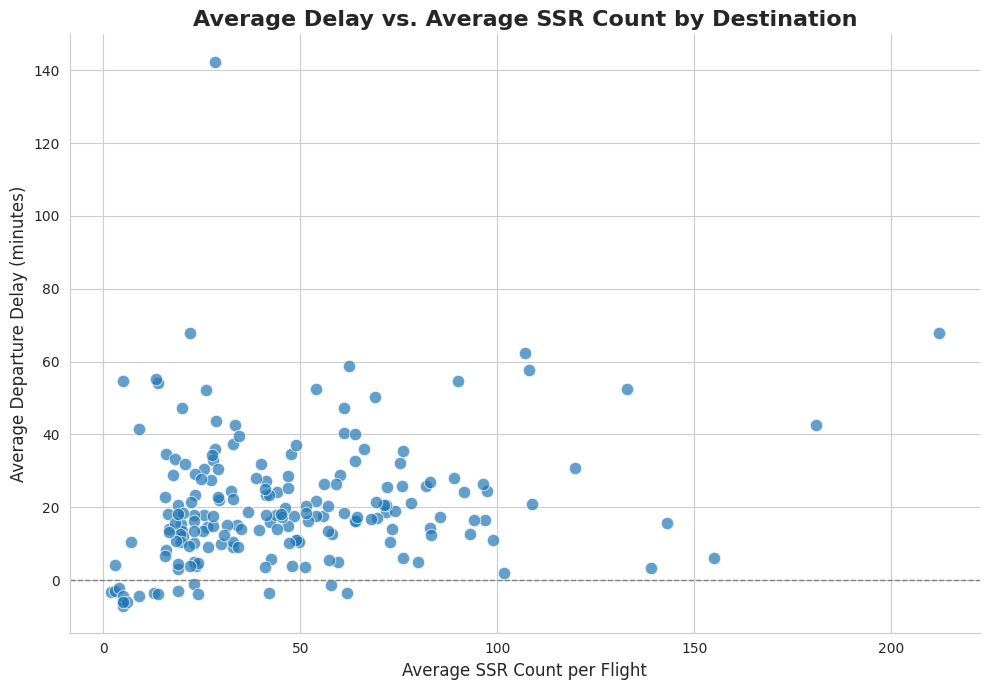

In [47]:
def create_destination_scatter_plot():

    #Analyzes and plots the relationship between the average SSR count
    #and the average departure delay for each destination airport.

    try:
        print("Loading flight and SSR data...")
        flight_df = pd.read_csv('Flight Level Data.csv')
        pnr_remark_df = pd.read_csv('PNR Remark Level Data.csv')

       # Prepare the data
        flight_df['scheduled_departure_datetime_local'] = pd.to_datetime(flight_df['scheduled_departure_datetime_local'])
        flight_df['actual_departure_datetime_local'] = pd.to_datetime(flight_df['actual_departure_datetime_local'])
        flight_df['departure_delay_min'] = (flight_df['actual_departure_datetime_local'] - flight_df['scheduled_departure_datetime_local']).dt.total_seconds() / 60
        flight_df['scheduled_departure_date'] = flight_df['scheduled_departure_datetime_local'].dt.date

        # Merge remarks data with flight data to get consistent dates
        ssr_with_date = pnr_remark_df.merge(flight_df[['flight_number', 'scheduled_departure_date']], on='flight_number', how='left')

        # Aggregate SSR counts per flight
        ssr_counts_per_flight = ssr_with_date.groupby(['flight_number', 'scheduled_departure_date']).size().reset_index(name='ssr_count')

        # Merge the SSR counts back into the main flight data
        analysis_df = flight_df.merge(ssr_counts_per_flight, on=['flight_number', 'scheduled_departure_date'], how='left')
        analysis_df['ssr_count'] = analysis_df['ssr_count'].fillna(0) # Flights with no SSRs get a count of 0

        # Aggregate Data by Destination
        # Group by destination and calculate the average delay and average SSR count
        destination_analysis = analysis_df.groupby('scheduled_arrival_station_code').agg(avg_delay_min=('departure_delay_min', 'mean'),
            avg_ssr_count=('ssr_count', 'mean')).reset_index()

        # Generate the Scatter Plot
        print("Generating scatter plot...")
        plt.figure(figsize=(10, 7))
        sns.set_style("whitegrid")

        ax = sns.scatterplot(
            data=destination_analysis,
            x='avg_ssr_count',
            y='avg_delay_min',
            s=80, # Size of the points
alpha=0.7)

        # Style the plot
        sns.despine()
        plt.title('Average Delay vs. Average SSR Count by Destination', fontsize=16, weight='bold')
        plt.xlabel('Average SSR Count per Flight', fontsize=12)
        plt.ylabel('Average Departure Delay (minutes)', fontsize=12)
        plt.axhline(0, color="grey", linestyle="--", linewidth=1) # Reference line for on-time departures

        plt.tight_layout()
        plt.savefig('destination_ssr_vs_delay_scatter.png')

        print("\nSuccessfully generated 'destination_ssr_vs_delay_scatter.png'")
        plt.show()

    except FileNotFoundError:
        print("\nERROR: Required CSV files not found. Please ensure they are uploaded.")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

# Run the function
if __name__ == '__main__':
    create_destination_scatter_plot()


Total Bags v/s Passengers

Loading flight, passenger (PNR), and bag data...
Generating scatter plot...

Successfully generated 'bags_vs_passengers_scatter.png'


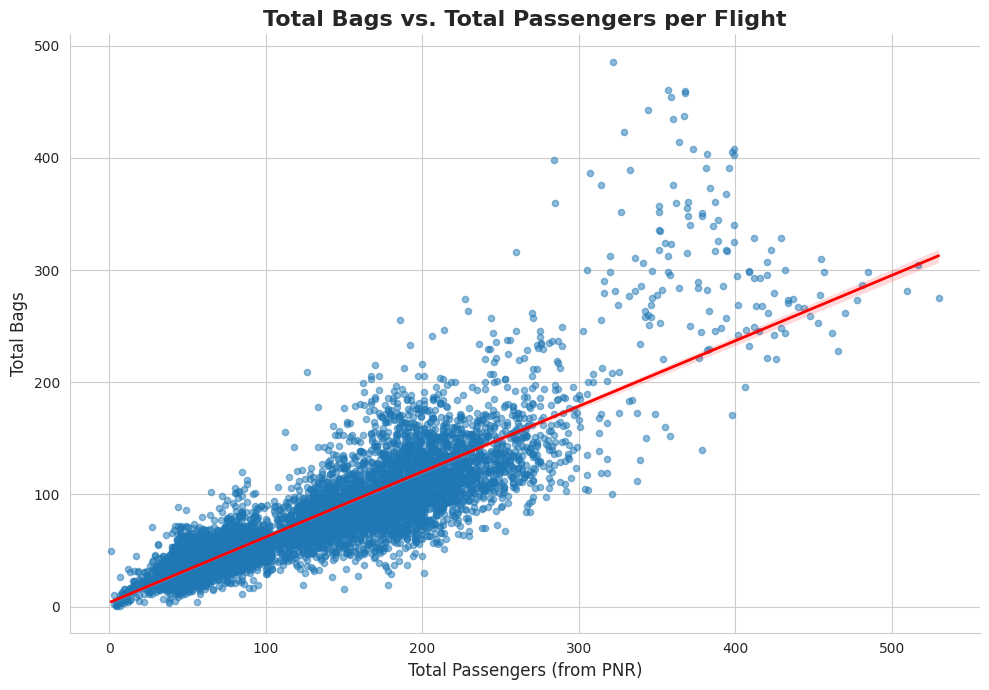

In [48]:


def create_bags_vs_pax_scatter():

    #Analyzes and plots the relationship between the total number of passengers
    #and the total number of bags for each flight.

    try:
        # Load the Necessary Data
        print("Loading flight, passenger (PNR), and bag data...")
        flight_df = pd.read_csv('Flight Level Data.csv')
        pnr_flight_df = pd.read_csv('PNR+Flight+Level+Data.csv')
        bag_df = pd.read_csv('Bag+Level+Data.csv')

        # Prepare the Data
        # Create a consistent date column for merging
        flight_df['scheduled_departure_date'] = pd.to_datetime(flight_df['scheduled_departure_date_local']).dt.date
        pnr_flight_df['scheduled_departure_date'] = pd.to_datetime(pnr_flight_df['scheduled_departure_date_local']).dt.date
        bag_df['scheduled_departure_date'] = pd.to_datetime(bag_df['scheduled_departure_date_local']).dt.date

        # Aggregate Data by Flight
        # Group by flight and date to get total passengers
        pax_agg = pnr_flight_df.groupby(['flight_number', 'scheduled_departure_date']).agg(
            total_pax=('total_pax', 'sum')
        ).reset_index()

        # Group by flight and date to get total bags
        bag_agg = bag_df.groupby(['flight_number', 'scheduled_departure_date']).agg(
            total_bags=('bag_tag_unique_number', 'count')
        ).reset_index()

        # Merge Passenger and Bag Data
        # Merge the two aggregated dataframes on flight number and date
        analysis_df = pd.merge(pax_agg, bag_agg, on=['flight_number', 'scheduled_departure_date'], how='inner')

        # Scatter Plot
        print("Generating scatter plot...")
        plt.figure(figsize=(10, 7))
        sns.set_style("whitegrid")

        # regplot to show both the scatter and the trendline
        sns.regplot(
            data=analysis_df,x='total_pax',y='total_bags',
            scatter_kws={'alpha': 0.5, 's': 20},line_kws={'color': 'red', 'lw': 2})

        # Style
        sns.despine()
        plt.title('Total Bags vs. Total Passengers per Flight', fontsize=16, weight='bold')
        plt.xlabel('Total Passengers (from PNR)', fontsize=12)
        plt.ylabel('Total Bags', fontsize=12)

        plt.tight_layout()
        plt.savefig('bags_vs_passengers_scatter.png')

        print("\nSuccessfully generated 'bags_vs_passengers_scatter.png'")
        plt.show()

    except FileNotFoundError:
        print("\nERROR: Required CSV files not found. Please ensure they are uploaded.")
    except Exception as e:
        print(f"\nAn error occurred: {e}")

# Run the function
if __name__ == '__main__':
    create_bags_vs_pax_scatter()
